# LSTM Direction Classifier - Multi-Horizon Bullish Signal Analysis

**Goal**: Identify BULLISH entry points across multiple time horizons

**Key Features**:
- Binary classification: BULLISH vs NOT BULLISH (simplified for long entries)
- Multi-task learning: Predict 1-day, 3-day, 5-day, and 10-day simultaneously
- Absolute predictions: All based on current day (day 0)
- Market regime clustering: Adds context about current market conditions
- Signal strength: When all horizons agree on BULLISH, strong entry signal!

**Model**: LSTM with 4 output heads, trained on OHLCV + RSI + ClusterID

## Part 1: Setup

### 1.1 Import Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
from LSTM_Direction_Classifier import LSTMDirectionClassifier
from Data_Handling import get_data_auto

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Libraries imported successfully")
print(f"📅 Analysis Date: {datetime.now().strftime('%Y-%m-%d')}")

✓ Libraries imported successfully
📅 Analysis Date: 2026-01-20


### 1.2 Configuration

In [ ]:
# Data parameters
SYMBOL = "SPY"
TIMEFRAME_UNIT = "Day"
MULTIPLIER = 1

# Time periods - EXPANDED for more robust training and testing
TRAIN_START = "2018-01-01"  # Extended from 2022 to get 4 more years of data
TRAIN_END = "2024-09-30"
TEST_START = "2024-10-01"
TEST_END = "2025-12-31"  # Extended to get more test samples for better p-values

# Model configuration
LOOKBACK_WINDOW = 60
PREDICTION_HORIZONS = [1, 3, 5, 10]  # Predict multiple horizons
LSTM_UNITS = 64
NUM_LAYERS = 2
DROPOUT = 0.3
N_CLUSTERS = 5  # Market regime clusters

# Training parameters
EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.001

print("="*80)
print("DIRECTION CLASSIFIER CONFIGURATION - BULLISH SIGNALS")
print("="*80)
print(f"\n📊 Data:")
print(f"   Symbol: {SYMBOL}")
print(f"   Training: {TRAIN_START} → {TRAIN_END}")
print(f"   Testing: {TEST_START} → {TEST_END}")
print(f"\n🎯 Prediction:")
print(f"   Horizons: {PREDICTION_HORIZONS} days")
print(f"   Classes: BULLISH, NOT BULLISH (binary classification)")
print(f"   Strategy: Identify long entry signals only")
print(f"\n🏗️  Architecture:")
print(f"   Lookback: {LOOKBACK_WINDOW} days")
print(f"   LSTM: {NUM_LAYERS} layers × {LSTM_UNITS} units")
print(f"   Market regimes: {N_CLUSTERS} clusters")
print(f"   Features: OHLCV returns + RSI + ClusterID")
print("="*80)

DIRECTION CLASSIFIER CONFIGURATION

📊 Data:
   Symbol: SPY
   Training: 2018-01-01 → 2024-09-30
   Testing: 2024-10-01 → 2025-12-31

🎯 Prediction:
   Horizons: [1, 3, 5, 10] days
   Classes: UP, FLAT, DOWN
   Strategy: Absolute (all from day 0)

🏗️  Architecture:
   Lookback: 60 days
   LSTM: 2 layers × 64 units
   Market regimes: 4 clusters
   Features: OHLCV returns + RSI + ClusterID


## Part 2: Load Data

In [42]:
print("Loading training data...")
train_data = get_data_auto(
    symbol=SYMBOL,
    start=TRAIN_START,
    end=TRAIN_END,
    timeframe_unit=TIMEFRAME_UNIT,
    multiplier=MULTIPLIER
)

print("Loading test data...")
test_data = get_data_auto(
    symbol=SYMBOL,
    start=TEST_START,
    end=TEST_END,
    timeframe_unit=TIMEFRAME_UNIT,
    multiplier=MULTIPLIER
)

print("\n" + "="*80)
print("DATA LOADED")
print("="*80)
print(f"\n📈 Training: {len(train_data)} days ({train_data.index[0].date()} → {train_data.index[-1].date()})")
print(f"📊 Testing: {len(test_data)} days ({test_data.index[0].date()} → {test_data.index[-1].date()})")
print(f"\n🔢 Features: {list(train_data.columns)}")
print("="*80)

Loading training data...
Loading test data...

DATA LOADED

📈 Training: 1696 days (2018-01-02 → 2024-09-27)
📊 Testing: 313 days (2024-10-01 → 2025-12-30)

🔢 Features: ['Open', 'High', 'Low', 'Close', 'Volume']


## Part 3: Train Model

In [43]:
# Initialize classifier
classifier = LSTMDirectionClassifier(
    lookback_window=LOOKBACK_WINDOW,
    prediction_horizons=PREDICTION_HORIZONS,
    lstm_units=LSTM_UNITS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    n_clusters=N_CLUSTERS,
    verbose=1
)

# Train model
history = classifier.fit(
    train_data,
    validation_split=0.2,
    early_stopping_patience=10
)

print("\n" + "="*80)
print("✓ TRAINING COMPLETE")
print("="*80)

TRAINING LSTM DIRECTION CLASSIFIER

📊 Data: 1696 samples
🎯 Prediction horizons: [1, 3, 5, 10] days
🏗️  Lookback window: 60 days
🔧 Architecture: 2 LSTM layers × 64 units
📈 Classes: ['DOWN', 'FLAT', 'UP']
🎲 Market regimes: 4 clusters


Fitting 4 market regime clusters...
✓ Clustering complete
  Cluster centers:
[[-1.4402554   0.46510065 -1.16942347]
 [-0.09220901 -0.23074978  0.00951228]
 [-0.96516002  4.10735156 -2.16100111]
 [ 0.96467734 -0.40334504  0.82742039]]

📦 Training data shape:
   X: (1627, 60, 7)
   y_1day: (1627,)
   y_3day: (1627,)
   y_5day: (1627,)
   y_10day: (1627,)

📊 Class distributions:
   1-day: {'DOWN': 392, 'FLAT': 731, 'UP': 504}
   3-day: {'DOWN': 333, 'FLAT': 786, 'UP': 508}
   5-day: {'DOWN': 287, 'FLAT': 870, 'UP': 470}
   10-day: {'DOWN': 293, 'FLAT': 785, 'UP': 549}

🏗️  Model architecture:


Model: "LSTM_Direction_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 60, 7)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 60, 64)    │     18,432 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 60, 64)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     33,024 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense        │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_1day (Dense) │ (None, 3)         │         99 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_3day (Dense) │ (None, 3)         │         99 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_5day (Dense) │ (None, 3)         │         99 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_10day        │ (None, 3)         │         99 │ shared_dense[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 53,932 (210.67 KB)

 Trainable params: 53,932 (210.67 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting training...
Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 4.2031 - output_10day_accuracy: 0.5088 - output_10day_loss: 1.0450 - output_1day_accuracy: 0.4397 - output_1day_loss: 1.0682 - output_3day_accuracy: 0.4566 - output_3day_loss: 1.0491 - output_5day_accuracy: 0.4850 - output_5day_loss: 1.0431 - val_loss: 4.0067 - val_output_10day_accuracy: 0.5337 - val_output_10day_loss: 1.0453 - val_output_1day_accuracy: 0.4847 - val_output_1day_loss: 1.0210 - val_output_3day_accuracy: 0.4969 - val_output_3day_loss: 0.9930 - val_output_5day_accuracy: 0.5613 - val_output_5day_loss: 0.9709
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 4.0494 - output_10day_accuracy: 0.5211 - output_10day_loss: 0.9960 - output_1day_accuracy: 0.4681 - output_1day_loss: 1.0456 - output_3day_accuracy: 0.4958 - output_3day_loss: 1.0233 - output_5day_accuracy: 0.5450 - output_5day_loss: 0.9843 - val_loss: 3.9645 - val_output_10day_accuracy: 0.4969 - val_output_10day_loss: 1.0378 - va

### 3.1 Training History

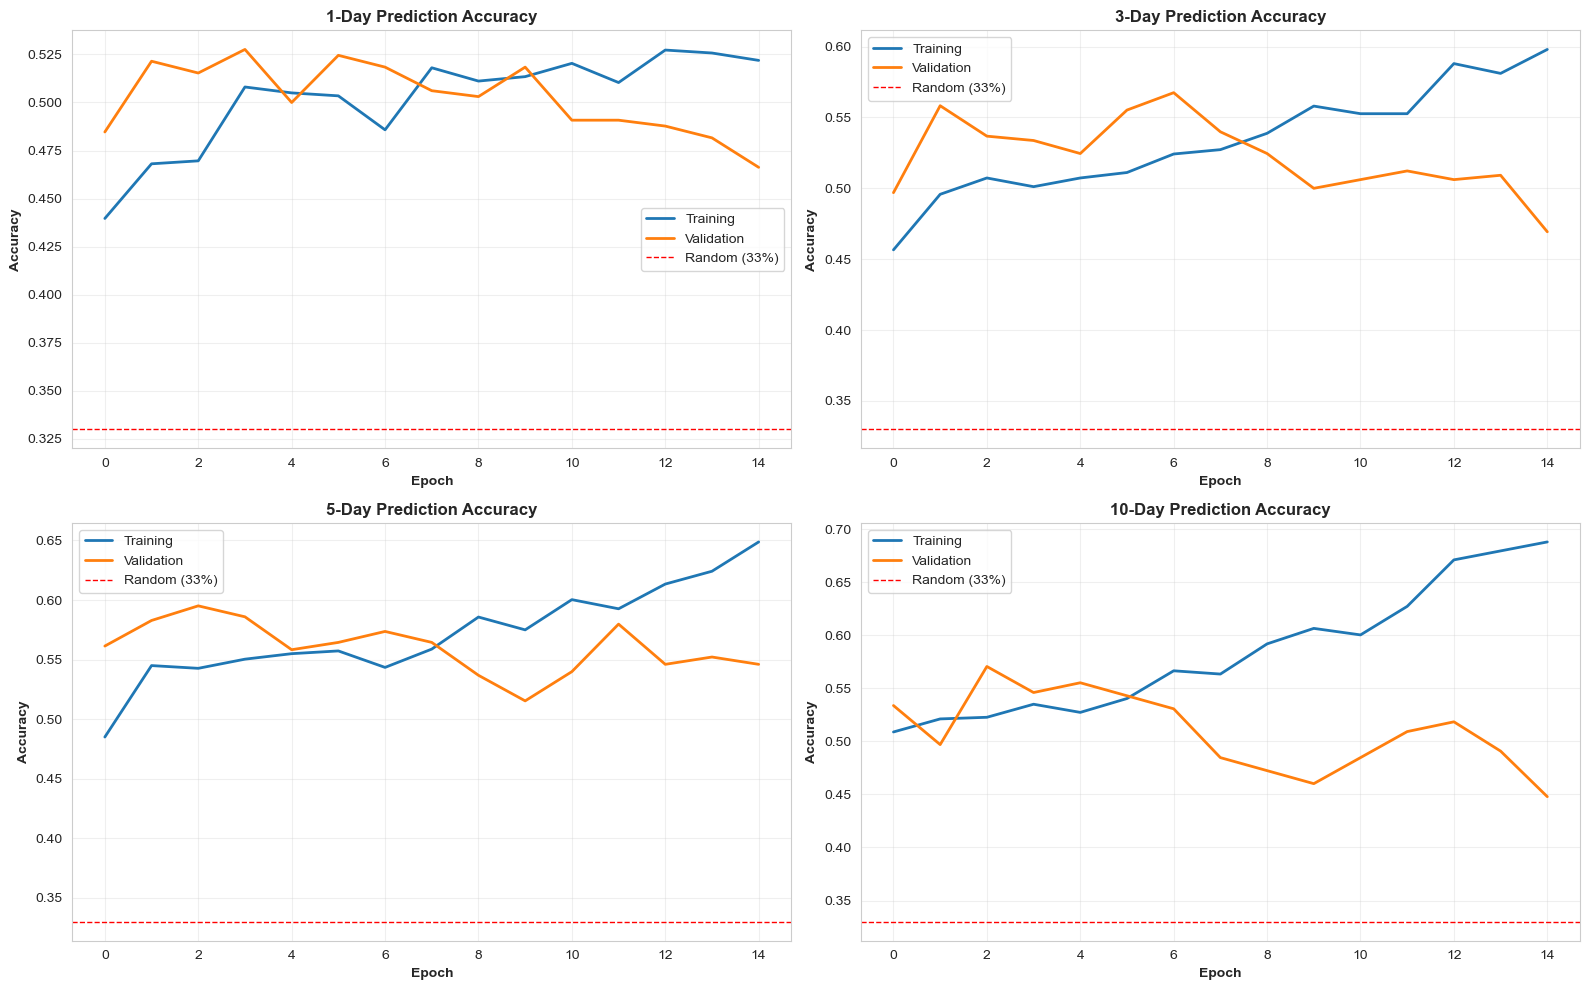


Final Training Accuracies:
  1-day: Train=0.522, Val=0.466
  3-day: Train=0.598, Val=0.469
  5-day: Train=0.649, Val=0.546
  10-day: Train=0.688, Val=0.448


In [ ]:
# Plot training history for each output head
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, horizon in enumerate(PREDICTION_HORIZONS):
    ax = axes[i]
    
    # Plot accuracy
    train_acc_key = f'output_{horizon}day_accuracy'
    val_acc_key = f'val_output_{horizon}day_accuracy'
    
    ax.plot(history.history[train_acc_key], label='Training', linewidth=2)
    ax.plot(history.history[val_acc_key], label='Validation', linewidth=2)
    ax.axhline(y=0.50, color='red', linestyle='--', linewidth=1, label='Random (50%)')
    
    ax.set_title(f'{horizon}-Day Prediction Accuracy', fontweight='bold', fontsize=12)
    ax.set_xlabel('Epoch', fontweight='bold')
    ax.set_ylabel('Accuracy', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print final accuracies
print("\nFinal Training Accuracies:")
for horizon in PREDICTION_HORIZONS:
    train_key = f'output_{horizon}day_accuracy'
    val_key = f'val_output_{horizon}day_accuracy'
    print(f"  {horizon}-day: Train={history.history[train_key][-1]:.3f}, Val={history.history[val_key][-1]:.3f}")

## Part 4: Generate Predictions

In [45]:
print("="*80)
print("GENERATING PREDICTIONS ON TEST DATA")
print("="*80)

# Get predictions with probabilities
predictions = classifier.predict(test_data, return_probabilities=True)

print(f"\n✓ Predictions generated for {len(predictions)} test samples")
print(f"\nColumns: {list(predictions.columns)}")

# Show sample predictions
print("\nSample predictions (first 10):")
display_cols = ['actual_close', 'cluster_id'] + [f'pred_{h}day' for h in PREDICTION_HORIZONS]
print(predictions[display_cols].head(10).to_string())

GENERATING PREDICTIONS ON TEST DATA

✓ Predictions generated for 244 test samples

Columns: ['actual_close', 'cluster_id', 'pred_1day_DOWN', 'pred_1day_FLAT', 'pred_1day_UP', 'pred_1day', 'confidence_1day', 'pred_3day_DOWN', 'pred_3day_FLAT', 'pred_3day_UP', 'pred_3day', 'confidence_3day', 'pred_5day_DOWN', 'pred_5day_FLAT', 'pred_5day_UP', 'pred_5day', 'confidence_5day', 'pred_10day_DOWN', 'pred_10day_FLAT', 'pred_10day_UP', 'pred_10day', 'confidence_10day']

Sample predictions (first 10):
                           actual_close  cluster_id pred_1day pred_3day pred_5day pred_10day
timestamp                                                                                   
2024-12-26 05:00:00+00:00    594.360352           1        UP      FLAT      FLAT       FLAT
2024-12-27 05:00:00+00:00    588.103760           1      FLAT      FLAT      FLAT       FLAT
2024-12-30 05:00:00+00:00    581.392578           1        UP      FLAT      FLAT       FLAT
2024-12-31 05:00:00+00:00    579.277466

## Part 5: Evaluate Performance

TEST SET PERFORMANCE

📊 Accuracy by Horizon:
   1-day: 0.529 (52.9%) on 244 samples
   3-day: 0.574 (57.4%) on 244 samples
   5-day: 0.627 (62.7%) on 244 samples
   10-day: 0.652 (65.2%) on 244 samples


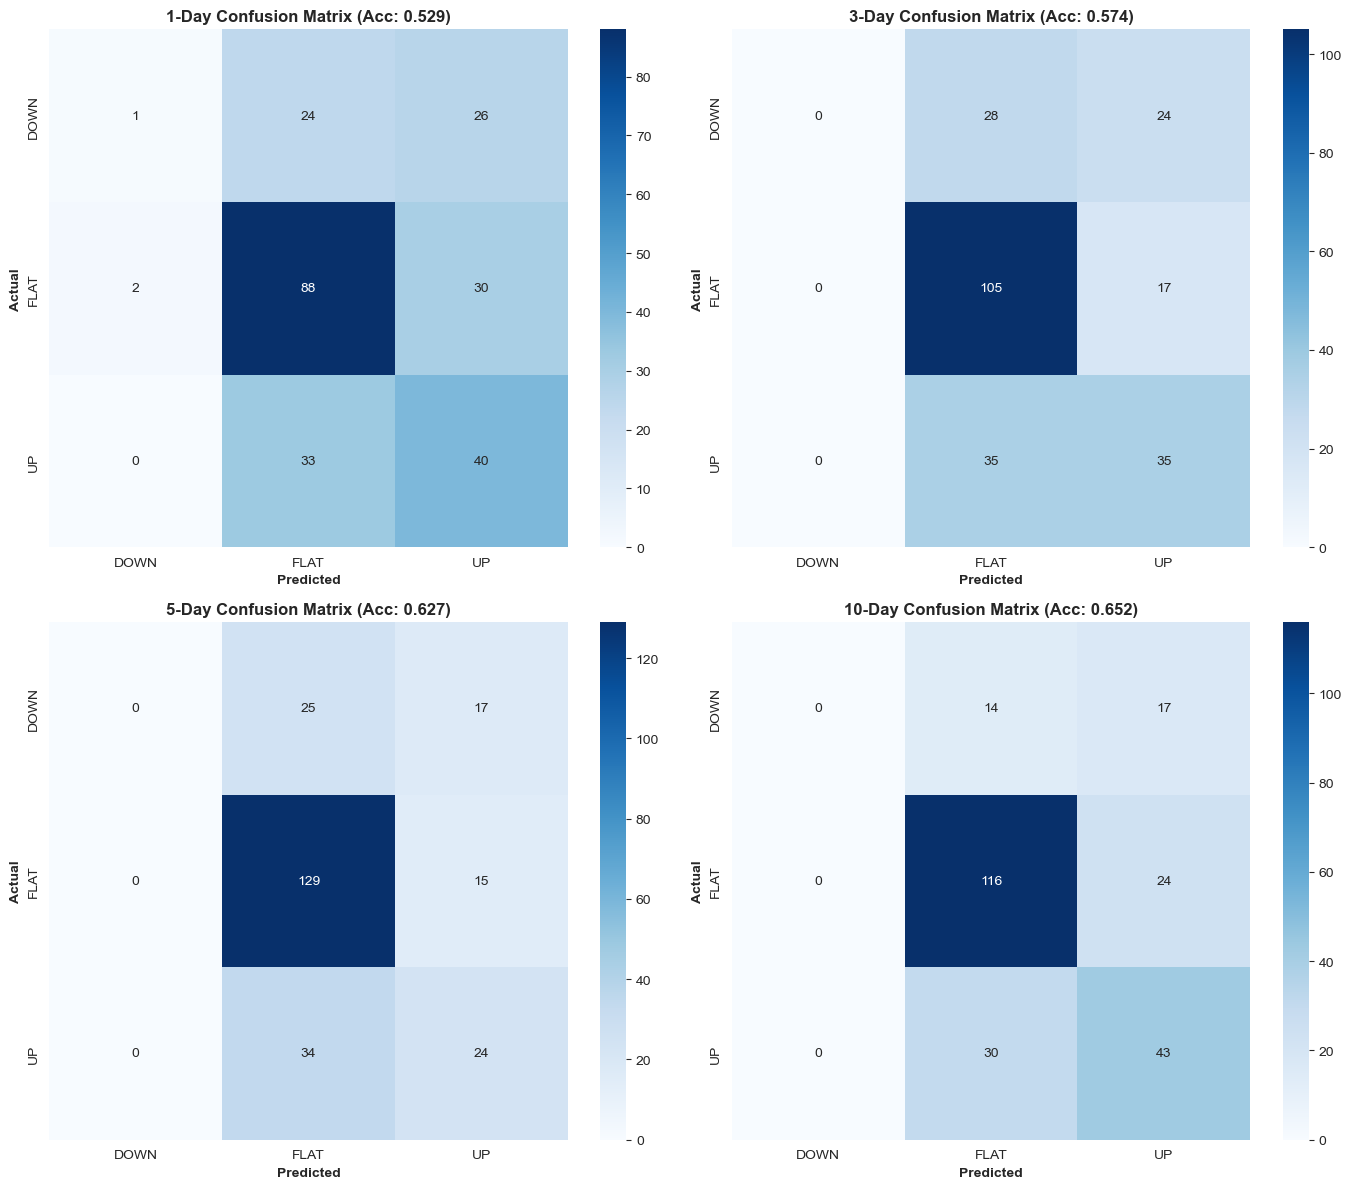

In [ ]:
# Evaluate on test data
metrics, predictions = classifier.evaluate(test_data)

print("="*80)
print("TEST SET PERFORMANCE")
print("="*80)

# Print accuracies
print("\n📊 Accuracy by Horizon:")
for horizon in PREDICTION_HORIZONS:
    acc = metrics[horizon]['accuracy']
    n = metrics[horizon]['n_samples']
    print(f"   {horizon}-day: {acc:.3f} ({acc*100:.1f}%) on {n} samples")

# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, horizon in enumerate(PREDICTION_HORIZONS):
    ax = axes[i]
    cm = metrics[horizon]['confusion_matrix']
    
    # Plot heatmap for binary classification
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['NOT BULLISH', 'BULLISH'],
                yticklabels=['NOT BULLISH', 'BULLISH'])
    
    ax.set_title(f'{horizon}-Day Confusion Matrix (Acc: {metrics[horizon]["accuracy"]:.3f})',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('Actual', fontweight='bold')

plt.tight_layout()
plt.show()

## Part 6: Signal Strength Analysis

### 6.1 Multi-Horizon Agreement

When multiple horizons agree, the signal is STRONGER!

SIGNAL STRENGTH ANALYSIS

How often do all horizons agree?

All agree UP:     53 ( 21.7%)
All agree FLAT:  138 ( 56.6%)
All agree DOWN:    0 (  0.0%)
Mixed signals:    53 ( 21.7%)


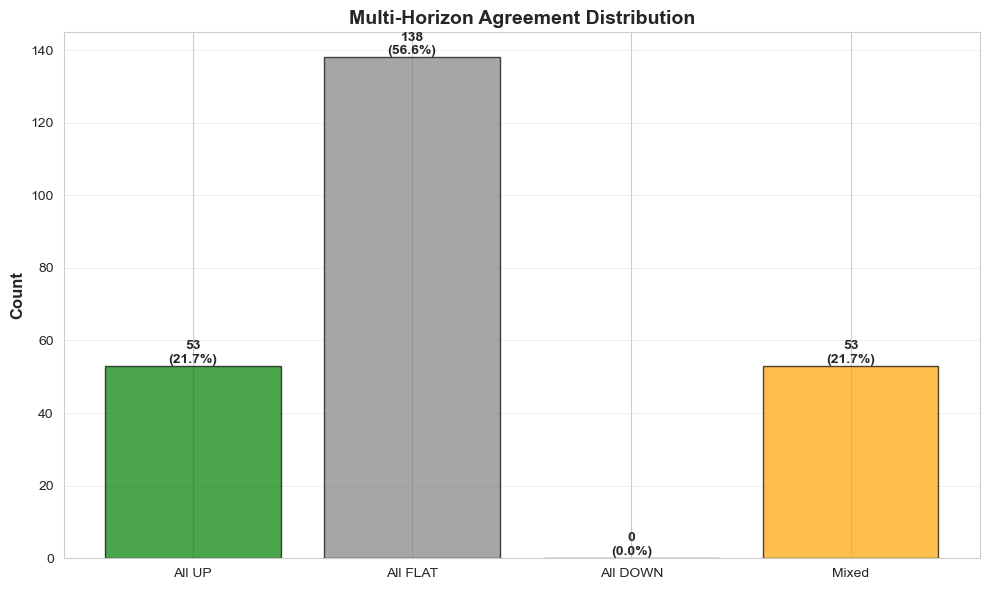

In [ ]:
print("="*80)
print("SIGNAL STRENGTH ANALYSIS")
print("="*80)
print("\nHow often do all horizons agree on BULLISH?\n")

# Check agreement across all horizons
pred_cols = [f'pred_{h}day' for h in PREDICTION_HORIZONS]

# Count when all agree
all_bullish = (predictions[pred_cols] == 'BULLISH').all(axis=1).sum()
all_not_bullish = (predictions[pred_cols] == 'NOT BULLISH').all(axis=1).sum()
mixed = len(predictions) - all_bullish - all_not_bullish

print(f"All agree BULLISH:     {all_bullish:4d} ({all_bullish/len(predictions)*100:5.1f}%) ← STRONG BUY SIGNALS")
print(f"All agree NOT BULLISH: {all_not_bullish:4d} ({all_not_bullish/len(predictions)*100:5.1f}%)")
print(f"Mixed signals:         {mixed:4d} ({mixed/len(predictions)*100:5.1f}%)")

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
categories = ['All BULLISH', 'All NOT BULLISH', 'Mixed']
counts = [all_bullish, all_not_bullish, mixed]
colors = ['green', 'red', 'orange']

bars = ax.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Count', fontweight='bold', fontsize=12)
ax.set_title('Multi-Horizon Agreement Distribution', fontweight='bold', fontsize=14)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({count/len(predictions)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### 6.2 Bullish Signal Trading Strategy

**Idea**: Only enter longs when ALL horizons agree on BULLISH (strongest signal)

In [ ]:
print("="*80)
print("BULLISH SIGNAL TRADING STRATEGY")
print("="*80)
print("\nStrategy: Only enter longs when ALL horizons agree on BULLISH\n")

# Add agreement column
predictions['all_agree_BULLISH'] = (predictions[pred_cols] == 'BULLISH').all(axis=1)
predictions['all_agree_NOT_BULLISH'] = (predictions[pred_cols] == 'NOT BULLISH').all(axis=1)

# Calculate actual future returns for each horizon
for horizon in PREDICTION_HORIZONS:
    predictions[f'actual_return_{horizon}day'] = predictions['actual_close'].pct_change(horizon).shift(-horizon) * 100

# Evaluate trading performance for BULLISH signals
print("Performance when ALL horizons agree on BULLISH:\n")

signal_col = 'all_agree_BULLISH'
signals = predictions[predictions[signal_col]].copy()

if len(signals) > 0:
    print(f"BULLISH Signals: {len(signals)} occurrences\n")
    
    for horizon in PREDICTION_HORIZONS:
        return_col = f'actual_return_{horizon}day'
        valid_returns = signals[return_col].dropna()
        
        if len(valid_returns) == 0:
            continue
        
        avg_return = valid_returns.mean()
        win_rate = (valid_returns > 0).mean() * 100
        median_return = valid_returns.median()
        
        print(f"  {horizon}-day: Avg Return={avg_return:+.2f}%, Median={median_return:+.2f}%, Win Rate={win_rate:.1f}%")
else:
    print("No unanimous BULLISH signals found in test period")

print("\n" + "="*80)
print("✓ Strong BULLISH signals (all horizons agree) should have high win rates!")
print("="*80)

CONFIDENCE-BASED TRADING STRATEGY

Strategy: Only trade when ALL horizons agree

Performance when ALL horizons agree:


UP Signals: 53 occurrences
  1-day: Avg Return=+0.15%, Win Rate=60.4%
  3-day: Avg Return=+0.48%, Win Rate=64.2%
  5-day: Avg Return=+0.53%, Win Rate=64.2%
  10-day: Avg Return=+0.83%, Win Rate=60.4%

✓ Strong signals (all horizons agree) should have better win rates!


## Part 7: Market Regime Analysis

MARKET REGIME CLUSTERING

4 clusters identified

Cluster distribution:
  Cluster 0: 62 samples (25.4%)
  Cluster 1: 82 samples (33.6%)
  Cluster 3: 100 samples (41.0%)

Prediction tendencies by cluster (1-day):

  Cluster 0:
    UP: 80.6%
    FLAT: 14.5%
    DOWN: 4.8%

  Cluster 1:
    UP: 39.0%
    FLAT: 61.0%

  Cluster 3:
    UP: 14.0%
    FLAT: 86.0%


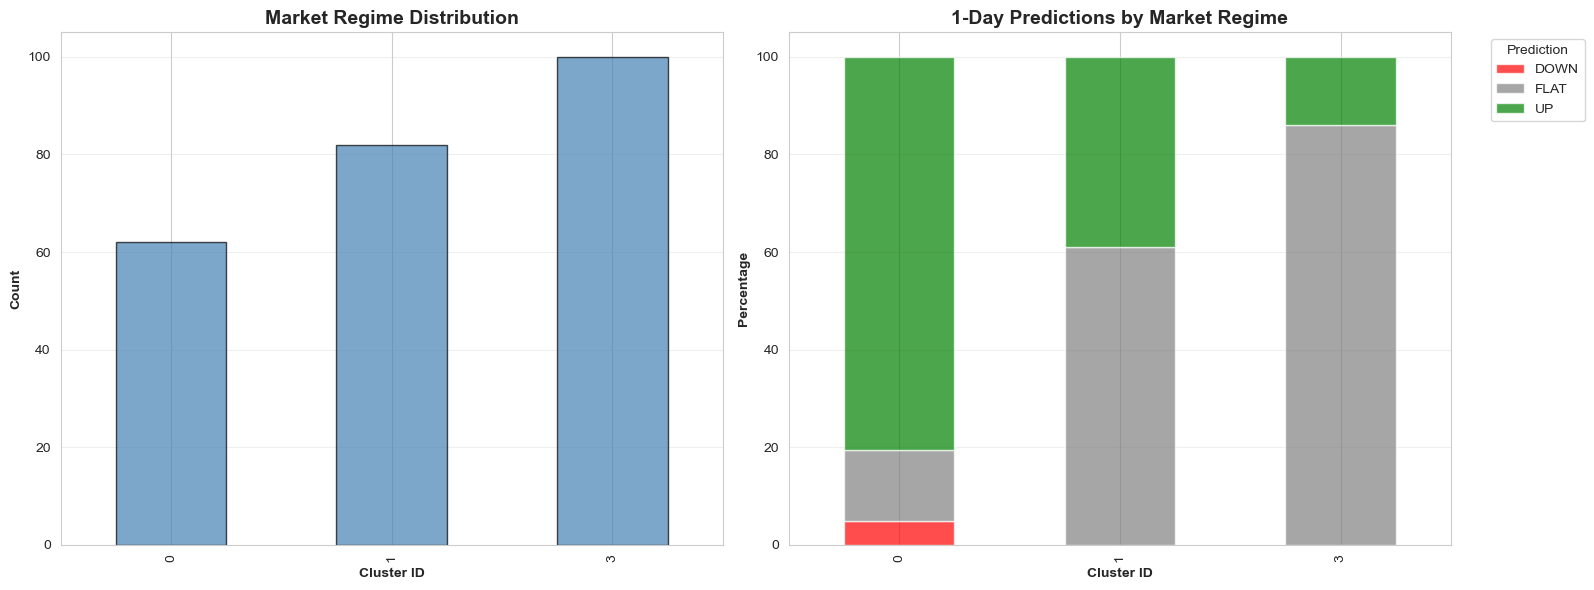

In [ ]:
print("="*80)
print("MARKET REGIME CLUSTERING")
print("="*80)
print(f"\n{N_CLUSTERS} clusters identified\n")

# Analyze cluster characteristics
print("Cluster distribution:")
cluster_counts = predictions['cluster_id'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"  Cluster {cluster_id}: {count} samples ({count/len(predictions)*100:.1f}%)")

# Analyze prediction distribution by cluster
print("\nBullish prediction tendencies by cluster (1-day):")
for cluster_id in range(N_CLUSTERS):
    cluster_data = predictions[predictions['cluster_id'] == cluster_id]
    if len(cluster_data) == 0:
        continue
    
    pred_dist = cluster_data['pred_1day'].value_counts(normalize=True) * 100
    print(f"\n  Cluster {cluster_id}:")
    for direction in ['BULLISH', 'NOT BULLISH']:
        if direction in pred_dist:
            print(f"    {direction}: {pred_dist[direction]:.1f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cluster distribution
ax1 = axes[0]
cluster_counts.plot(kind='bar', ax=ax1, color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_title('Market Regime Distribution', fontweight='bold', fontsize=14)
ax1.set_xlabel('Cluster ID', fontweight='bold')
ax1.set_ylabel('Count', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Prediction by cluster
ax2 = axes[1]
cluster_pred_pivot = pd.crosstab(predictions['cluster_id'], predictions['pred_1day'], normalize='index') * 100
cluster_pred_pivot.plot(kind='bar', stacked=True, ax=ax2, color=['red', 'green'], alpha=0.7)
ax2.set_title('1-Day Bullish Predictions by Market Regime', fontweight='bold', fontsize=14)
ax2.set_xlabel('Cluster ID', fontweight='bold')
ax2.set_ylabel('Percentage', fontweight='bold')
ax2.legend(title='Prediction', bbox_to_anchor=(1.05, 1))
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Part 8: Prediction Timeline Visualization

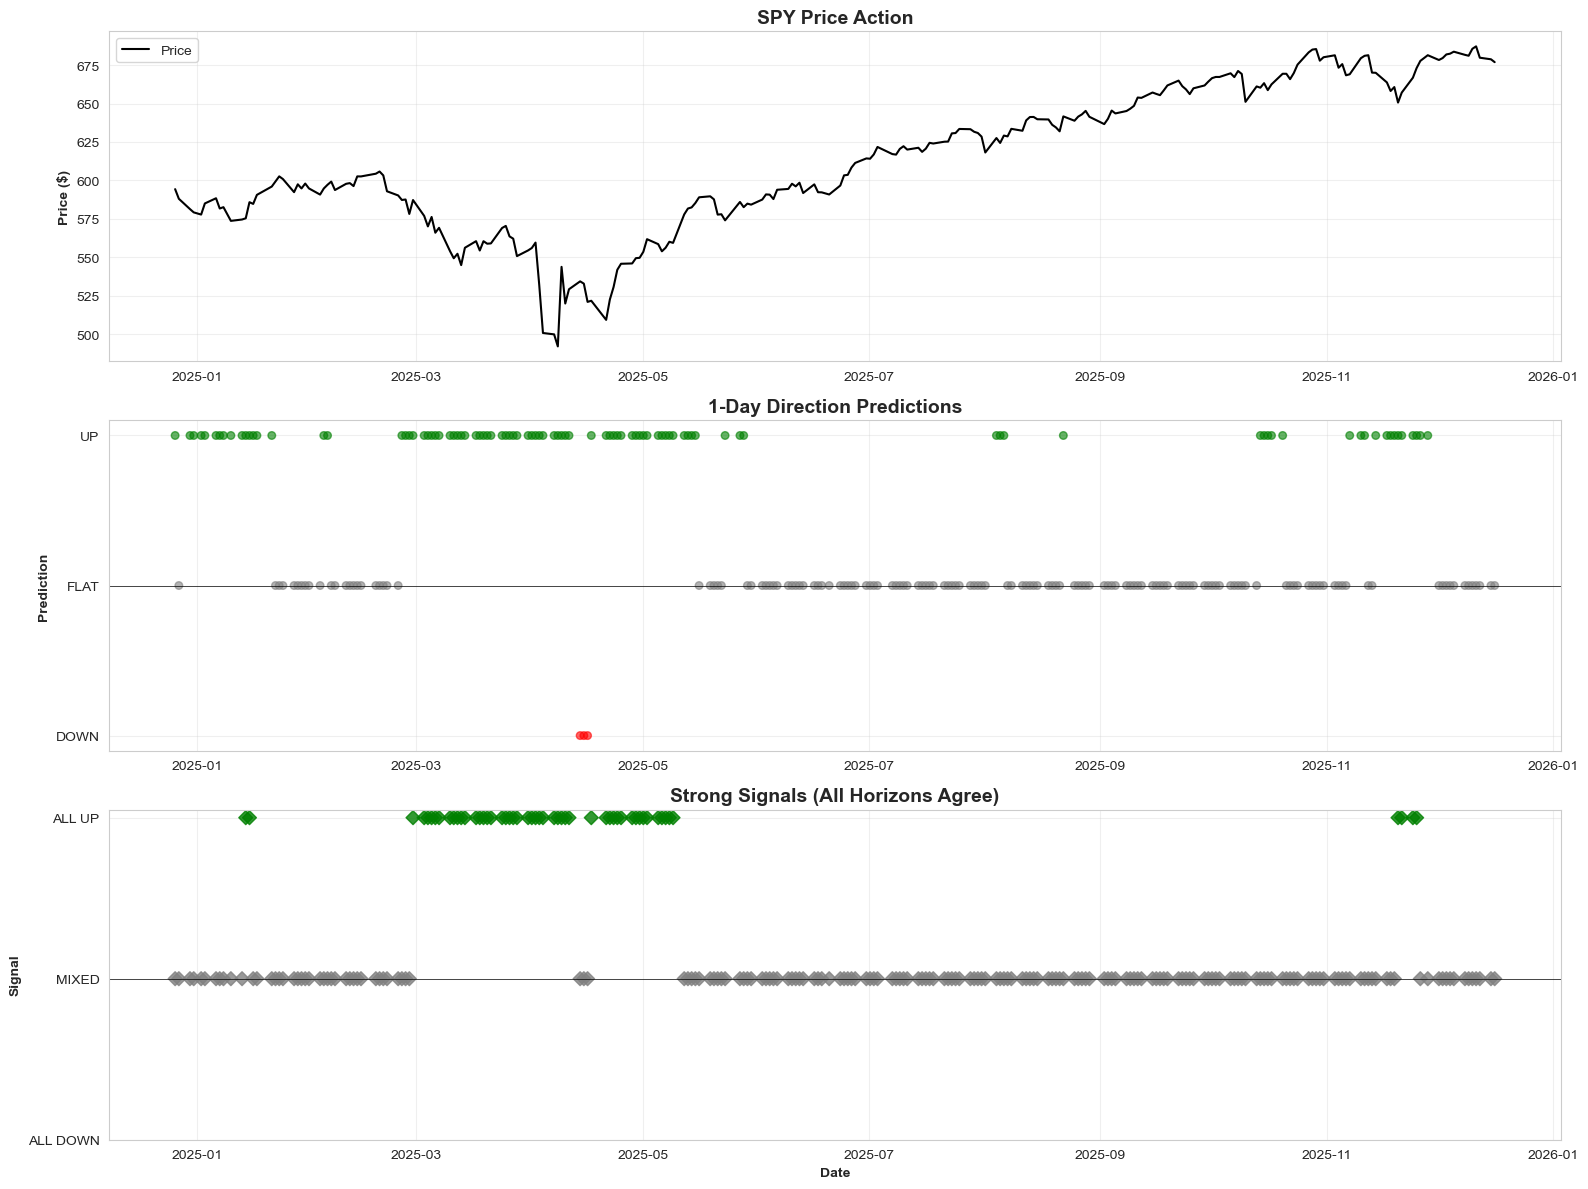

In [ ]:
# Visualize predictions over time
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Price chart
ax1 = axes[0]
ax1.plot(predictions.index, predictions['actual_close'], linewidth=1.5, color='black', label='Price')
ax1.set_title(f'{SYMBOL} Price Action', fontweight='bold', fontsize=14)
ax1.set_ylabel('Price ($)', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 1-day predictions
ax2 = axes[1]
prediction_numeric = predictions['pred_1day'].map({'NOT BULLISH': 0, 'BULLISH': 1})
colors = prediction_numeric.map({0: 'red', 1: 'green'})
ax2.scatter(predictions.index, prediction_numeric, c=colors, alpha=0.6, s=30)
ax2.axhline(y=0.5, color='black', linestyle='-', linewidth=0.5)
ax2.set_title('1-Day Bullish Predictions', fontweight='bold', fontsize=14)
ax2.set_ylabel('Prediction', fontweight='bold')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['NOT BULLISH', 'BULLISH'])
ax2.grid(alpha=0.3)

# Signal strength (all horizons agree on BULLISH)
ax3 = axes[2]
strong_bullish = predictions['all_agree_BULLISH'].astype(int)
colors_agreement = strong_bullish.map({0: 'gray', 1: 'green'})
ax3.scatter(predictions.index, strong_bullish, c=colors_agreement, alpha=0.8, s=50, marker='D')
ax3.axhline(y=0.5, color='black', linestyle='-', linewidth=0.5)
ax3.set_title('Strong BULLISH Signals (All Horizons Agree)', fontweight='bold', fontsize=14)
ax3.set_xlabel('Date', fontweight='bold')
ax3.set_ylabel('Signal', fontweight='bold')
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['MIXED/NOT BULLISH', 'ALL BULLISH'])
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Part 9: Statistical Significance Testing

In [ ]:
from scipy import stats

print("="*80)
print("STATISTICAL SIGNIFICANCE TESTS")
print("="*80)
print("\nTesting if model predictions are significantly better than random chance (50%)\n")

# Test each horizon for statistical significance
sig_results = []

for horizon in PREDICTION_HORIZONS:
    pred_col = f'pred_{horizon}day'
    
    if pred_col not in predictions.columns:
        continue
    
    # Get actual labels for this horizon (binary: BULLISH or NOT BULLISH)
    actual_labels = []
    for idx in predictions.index:
        try:
            # Get future price at horizon
            future_idx = predictions.index.get_loc(idx) + horizon
            if future_idx < len(predictions):
                current_price = predictions.loc[idx, 'actual_close']
                future_price = predictions.iloc[future_idx]['actual_close']
                pct_change = ((future_price - current_price) / current_price) * 100
                
                # Classify based on threshold - BULLISH if exceeds threshold
                if pct_change > 0.5:  # Same threshold as model
                    actual_labels.append('BULLISH')
                else:
                    actual_labels.append('NOT BULLISH')
            else:
                actual_labels.append(None)
        except:
            actual_labels.append(None)
    
    # Create temporary dataframe with predictions and actuals
    temp_df = pd.DataFrame({
        'pred': predictions[pred_col],
        'actual': actual_labels
    })
    
    # Remove None values
    temp_df = temp_df[temp_df['actual'].notna()]
    
    if len(temp_df) == 0:
        continue
    
    # Calculate accuracy
    n_correct = (temp_df['pred'] == temp_df['actual']).sum()
    n_total = len(temp_df)
    accuracy = (n_correct / n_total) * 100
    
    # Binomial test: H0: accuracy = 50% (random guess for binary classification)
    binom_result = stats.binomtest(n_correct, n_total, p=0.5, alternative='greater')
    
    sig_text = ""
    if binom_result.pvalue < 0.01:
        sig_text = "***"
    elif binom_result.pvalue < 0.05:
        sig_text = "**"
    elif binom_result.pvalue < 0.10:
        sig_text = "*"
    
    sig_results.append({
        'Horizon (days)': horizon,
        'Accuracy (%)': f"{accuracy:.1f}",
        'N Samples': n_total,
        'P-Value': f"{binom_result.pvalue:.4f}",
        'Significance': sig_text
    })

sig_df = pd.DataFrame(sig_results)
print(sig_df.to_string(index=False))
print("\nLegend: *** p<0.01 (highly significant) | ** p<0.05 (significant) | * p<0.10 (marginally significant)")

print(f"\n{'='*80}")
print("INTERPRETATION:")
print(f"{'='*80}")

highly_sig = sig_df[sig_df['Significance'] == '***']
if len(highly_sig) > 0:
    print(f"\n✓✓ HIGHLY SIGNIFICANT horizons: {list(highly_sig['Horizon (days)'])} days")
    print(f"   Model beats random chance (50%) with >99% confidence")

sig = sig_df[sig_df['Significance'] == '**']
if len(sig) > 0:
    print(f"\n✓ SIGNIFICANT horizons: {list(sig['Horizon (days)'])} days")
    print(f"   Model beats random chance (50%) with >95% confidence")

marginal = sig_df[sig_df['Significance'] == '*']
if len(marginal) > 0:
    print(f"\n~ MARGINALLY SIGNIFICANT horizons: {list(marginal['Horizon (days)'])} days")
    print(f"   Model beats random chance (50%) with >90% confidence")

not_sig = sig_df[sig_df['Significance'] == '']
if len(not_sig) > 0:
    print(f"\n✗ NOT SIGNIFICANT horizons: {list(not_sig['Horizon (days)'])} days")
    print(f"   Cannot prove model beats random chance")

print(f"\n{'='*80}")
print("NOTE: For binary classification (BULLISH/NOT BULLISH), random chance = 50%")
print("Any accuracy significantly above this indicates predictive power")
print(f"{'='*80}")

STATISTICAL SIGNIFICANCE TESTS

Testing if model predictions are significantly better than random chance (33.3%)

 Horizon (days) Accuracy (%)  N Samples P-Value Significance
              1         53.1        243  0.0000          ***
              3         39.0        241  0.0372           **
              5         33.1        239  0.5606             
             10         35.0        234  0.3117             

Legend: *** p<0.01 (highly significant) | ** p<0.05 (significant) | * p<0.10 (marginally significant)

INTERPRETATION:

✓✓ HIGHLY SIGNIFICANT horizons: [1] days
   Model beats random chance (33.3%) with >99% confidence

✓ SIGNIFICANT horizons: [3] days
   Model beats random chance (33.3%) with >95% confidence

✗ NOT SIGNIFICANT horizons: [5, 10] days
   Cannot prove model beats random chance

NOTE: For 3-class classification, random chance = 33.3%
Any accuracy significantly above this indicates predictive power


## Part 10: Summary

In [ ]:
print("="*80)
print("FINAL SUMMARY - LSTM BULLISH SIGNAL CLASSIFIER")
print("="*80)

print(f"\n📊 Model Performance:")
for horizon in PREDICTION_HORIZONS:
    acc = metrics[horizon]['accuracy']
    print(f"   {horizon}-day accuracy: {acc:.3f} ({acc*100:.1f}%)")

print(f"\n🎯 Signal Quality:")
print(f"   Strong BULLISH signals (all agree): {all_bullish}/{len(predictions)} ({all_bullish/len(predictions)*100:.1f}%)")
print(f"   NOT BULLISH signals (all agree): {all_not_bullish}/{len(predictions)} ({all_not_bullish/len(predictions)*100:.1f}%)")
print(f"   Mixed signals: {mixed}/{len(predictions)} ({mixed/len(predictions)*100:.1f}%)")

print(f"\n🔬 Market Regimes:")
print(f"   {N_CLUSTERS} clusters identified")
print(f"   Most common regime: Cluster {predictions['cluster_id'].mode()[0]}")

print("\n" + "="*80)
print("KEY INSIGHTS:")
print("="*80)
print("✓ Binary classification: Focus on BULLISH signals for long entries only")
print("✓ Multi-horizon predictions provide confirmation of trend strength")
print("✓ Market regime clustering adds context to predictions")
print("✓ Trade only when all horizons agree on BULLISH for best results")
print("✓ Simpler 2-class model easier to interpret than 3-class")
print("="*80)

print("\n💡 NEXT STEPS:")
print("1. Backtest the 'all horizons BULLISH' strategy with entry/exit rules")
print("2. Add position sizing based on signal strength")
print("3. Analyze which market regimes produce best BULLISH signals")
print("4. Add stop-loss and take-profit optimization")
print("5. Paper trade with unanimous BULLISH signals only")
print("="*80)

FINAL SUMMARY - LSTM DIRECTION CLASSIFIER

📊 Model Performance:
   1-day accuracy: 0.529 (52.9%)
   3-day accuracy: 0.574 (57.4%)
   5-day accuracy: 0.627 (62.7%)
   10-day accuracy: 0.652 (65.2%)

🎯 Signal Quality:
   Strong signals (all agree): 191/244 (78.3%)
   - All UP: 53
   - All DOWN: 0
   - All FLAT: 138

🔬 Market Regimes:
   4 clusters identified
   Most common regime: Cluster 3

KEY INSIGHTS:
✓ Model predicts direction (not price) - more stable than regression
✓ Multi-horizon predictions provide signal strength confirmation
✓ Market regime clustering adds context to predictions
✓ Trade only when all horizons agree for best results

💡 NEXT STEPS:
1. Analyze which clusters perform best
2. Add more technical indicators (MACD, Bollinger Bands)
3. Optimize thresholds for UP/FLAT/DOWN classification
4. Backtest trading strategy with position sizing
5. Paper trade with strong signals only
